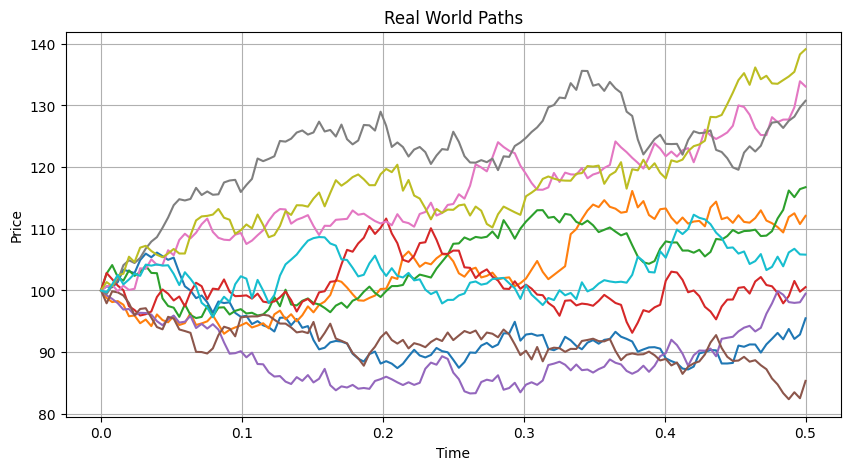

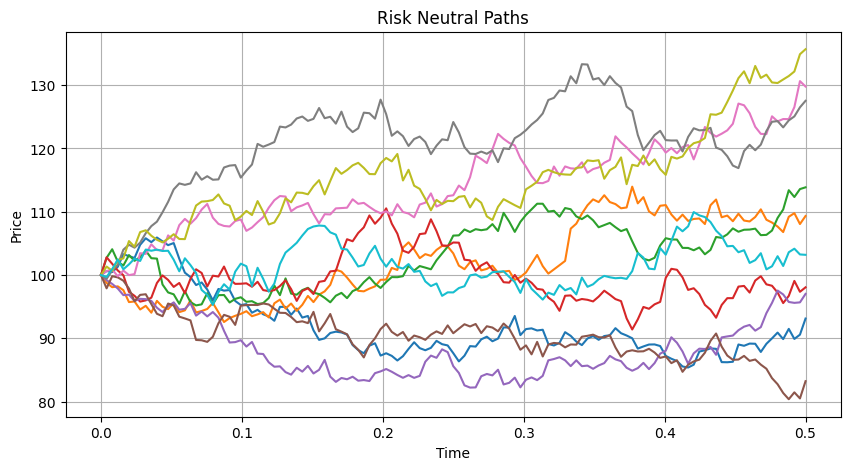


Asian Option Prices

K = 105
Call: 1.793435, CI: [1.769834, 1.817035]
Put : 5.463614, CI: [5.428378, 5.498849]

K = 110
Call: 0.709297, CI: [0.694541, 0.724054]
Put : 9.256026, CI: [9.213257, 9.298795]

K = 90
Call: 11.212748, CI: [11.164952, 11.260544]
Put : 0.253278, CI: [0.246296, 0.260261]



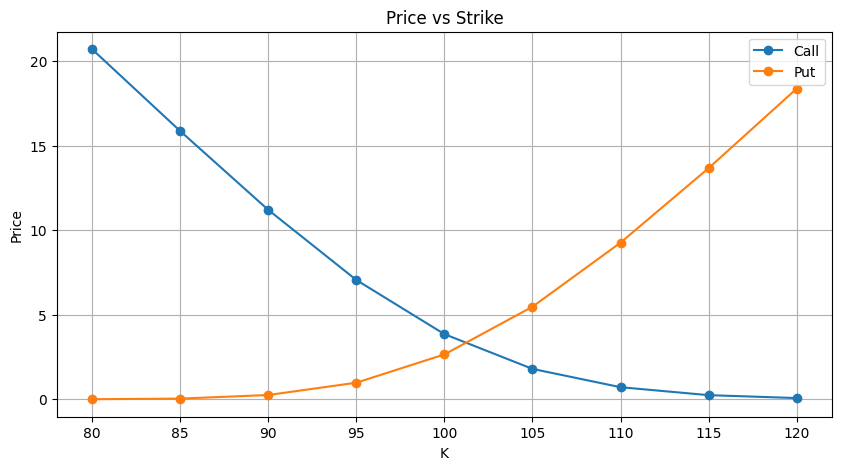

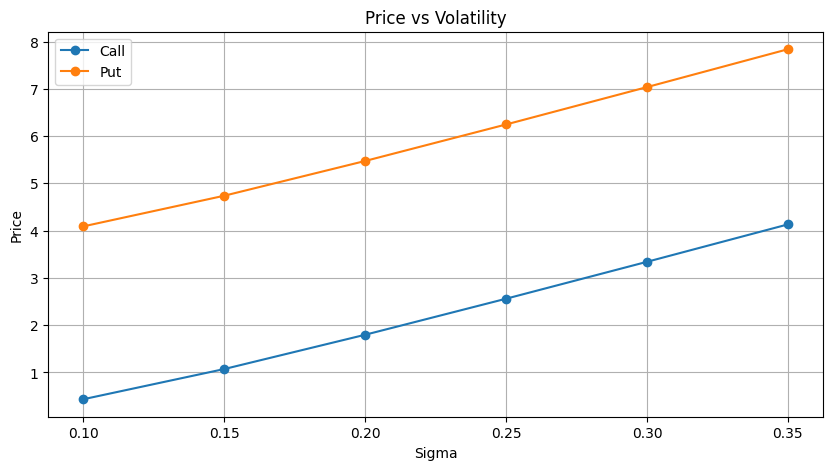

In [1]:
import numpy as np
import matplotlib.pyplot as plt

MU = 0.10
SIGMA = 0.20
R = 0.05
S0 = 100.0
T = 0.5

N_STEPS = 126
N_PATHS_PRICE = 100000
N_PATHS_PLOT = 10
SEED = 42


def simulate_gbm_paths(S0, drift, sigma, T, n_steps, n_paths, seed=None):
    if seed is not None:
        np.random.seed(seed)

    dt = T / n_steps
    t_grid = np.linspace(0, T, n_steps + 1)

    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = S0

    Z = np.random.randn(n_paths, n_steps)

    for i in range(1, n_steps + 1):
        paths[:, i] = paths[:, i - 1] * np.exp(
            (drift - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, i - 1]
        )

    return t_grid, paths


def asian_option_price_mc(S0, K, r, sigma, T, n_steps, n_paths, option_type="call", seed=None):
    _, paths = simulate_gbm_paths(S0, r, sigma, T, n_steps, n_paths, seed=seed)

    avg_price = np.mean(paths[:, 1:], axis=1)

    if option_type == "call":
        payoffs = np.maximum(avg_price - K, 0.0)
    else:
        payoffs = np.maximum(K - avg_price, 0.0)

    discounted = np.exp(-r * T) * payoffs

    price = np.mean(discounted)
    std_error = np.std(discounted, ddof=1) / np.sqrt(n_paths)

    ci_low = price - 1.96 * std_error
    ci_high = price + 1.96 * std_error

    return price, std_error, ci_low, ci_high


def sensitivity_by_strike(S0, r, sigma, T, n_steps, n_paths, strikes, seed=None):
    call_prices = []
    put_prices = []

    for K in strikes:
        c, _, _, _ = asian_option_price_mc(S0, K, r, sigma, T, n_steps, n_paths, "call", seed)
        p, _, _, _ = asian_option_price_mc(S0, K, r, sigma, T, n_steps, n_paths, "put", seed)
        call_prices.append(c)
        put_prices.append(p)

    return np.array(call_prices), np.array(put_prices)


def sensitivity_by_volatility(S0, K, r, sigmas, T, n_steps, n_paths, seed=None):
    call_prices = []
    put_prices = []

    for s in sigmas:
        c, _, _, _ = asian_option_price_mc(S0, K, r, s, T, n_steps, n_paths, "call", seed)
        p, _, _, _ = asian_option_price_mc(S0, K, r, s, T, n_steps, n_paths, "put", seed)
        call_prices.append(c)
        put_prices.append(p)

    return np.array(call_prices), np.array(put_prices)


if __name__ == "__main__":

    t_real, real_paths = simulate_gbm_paths(S0, MU, SIGMA, T, N_STEPS, N_PATHS_PLOT, seed=SEED)
    t_rn, rn_paths = simulate_gbm_paths(S0, R, SIGMA, T, N_STEPS, N_PATHS_PLOT, seed=SEED)

    plt.figure(figsize=(10, 5))
    for i in range(N_PATHS_PLOT):
        plt.plot(t_real, real_paths[i])
    plt.title("Real World Paths")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.grid()
    plt.show()

    plt.figure(figsize=(10, 5))
    for i in range(N_PATHS_PLOT):
        plt.plot(t_rn, rn_paths[i])
    plt.title("Risk Neutral Paths")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.grid()
    plt.show()

    strikes = [105, 110, 90]

    print("\nAsian Option Prices\n")

    for K in strikes:
        c, c_se, c_lo, c_hi = asian_option_price_mc(S0, K, R, SIGMA, T, N_STEPS, N_PATHS_PRICE, "call", SEED)
        p, p_se, p_lo, p_hi = asian_option_price_mc(S0, K, R, SIGMA, T, N_STEPS, N_PATHS_PRICE, "put", SEED)

        print(f"K = {K}")
        print(f"Call: {c:.6f}, CI: [{c_lo:.6f}, {c_hi:.6f}]")
        print(f"Put : {p:.6f}, CI: [{p_lo:.6f}, {p_hi:.6f}]\n")

    strike_grid = np.array([80, 85, 90, 95, 100, 105, 110, 115, 120])
    call_K, put_K = sensitivity_by_strike(S0, R, SIGMA, T, N_STEPS, N_PATHS_PRICE // 2, strike_grid, SEED)

    plt.figure(figsize=(10, 5))
    plt.plot(strike_grid, call_K, marker="o", label="Call")
    plt.plot(strike_grid, put_K, marker="o", label="Put")
    plt.title("Price vs Strike")
    plt.xlabel("K")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()

    sigma_grid = np.array([0.10, 0.15, 0.20, 0.25, 0.30, 0.35])
    K0 = 105

    call_s, put_s = sensitivity_by_volatility(S0, K0, R, sigma_grid, T, N_STEPS, N_PATHS_PRICE // 2, SEED)

    plt.figure(figsize=(10, 5))
    plt.plot(sigma_grid, call_s, marker="o", label="Call")
    plt.plot(sigma_grid, put_s, marker="o", label="Put")
    plt.title("Price vs Volatility")
    plt.xlabel("Sigma")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()

In [4]:
import numpy as np
from math import erf, sqrt, exp, log

# -----------------------------
# Problem settings
# -----------------------------
S0 = 100.0
r = 0.05
sigma = 0.20
T = 0.5   # 6 months

# -----------------------------
# Small helpers
# -----------------------------
def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_price(S0, K, T, r, sigma, option_type="call"):
    """Black-Scholes price for the European control variate."""
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)

    if option_type == "call":
        return S0 * norm_cdf(d1) - K * exp(-r * T) * norm_cdf(d2)
    else:
        return K * exp(-r * T) * norm_cdf(-d2) - S0 * norm_cdf(-d1)

def asian_payoff(avg_price, K, option_type="call"):
    if option_type == "call":
        return np.maximum(avg_price - K, 0.0)
    else:
        return np.maximum(K - avg_price, 0.0)

def european_payoff(ST, K, option_type="call"):
    if option_type == "call":
        return np.maximum(ST - K, 0.0)
    else:
        return np.maximum(K - ST, 0.0)

def simulate_paths_from_Z(Z, S0, r, sigma, T):
    """
    Simulate GBM paths from standard normal shocks Z.
    Z shape: (n_paths, n_steps)
    Returns prices at monitoring dates, excluding S0.
    """
    n_paths, n_steps = Z.shape
    dt = T / n_steps
    drift = (r - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)

    log_increments = drift + vol * Z
    log_paths = np.cumsum(log_increments, axis=1)
    S = S0 * np.exp(log_paths)
    return S

# -----------------------------
# Pricing functions
# -----------------------------
def price_asian_mc(K, option_type="call", method="plain",
                   n_paths=50000, n_steps=50, seed=123):
    """
    method = 'plain' | 'antithetic' | 'control_variate'
    Returns: (price, standard_error)
    """
    rng = np.random.default_rng(seed)
    disc = np.exp(-r * T)

    if method == "plain":
        Z = rng.normal(size=(n_paths, n_steps))
        S = simulate_paths_from_Z(Z, S0, r, sigma, T)

        A = S.mean(axis=1)                      # arithmetic average
        payoff = disc * asian_payoff(A, K, option_type)

        price = payoff.mean()
        se = payoff.std(ddof=1) / np.sqrt(n_paths)
        return price, se

    elif method == "antithetic":
        m = n_paths // 2
        Z = rng.normal(size=(m, n_steps))

        S_plus = simulate_paths_from_Z(Z, S0, r, sigma, T)
        S_minus = simulate_paths_from_Z(-Z, S0, r, sigma, T)

        A_plus = S_plus.mean(axis=1)
        A_minus = S_minus.mean(axis=1)

        payoff_plus = asian_payoff(A_plus, K, option_type)
        payoff_minus = asian_payoff(A_minus, K, option_type)

        pair_avg = disc * 0.5 * (payoff_plus + payoff_minus)

        price = pair_avg.mean()
        se = pair_avg.std(ddof=1) / np.sqrt(m)
        return price, se

    elif method == "control_variate":
        Z = rng.normal(size=(n_paths, n_steps))
        S = simulate_paths_from_Z(Z, S0, r, sigma, T)

        A = S.mean(axis=1)          # Asian average
        ST = S[:, -1]               # terminal stock price

        X = disc * asian_payoff(A, K, option_type)        # target
        Y = disc * european_payoff(ST, K, option_type)    # control

        EY = bs_price(S0, K, T, r, sigma, option_type)    # exact control mean

        # optimal control coefficient
        cov_xy = np.cov(X, Y, ddof=1)[0, 1]
        var_y = np.var(Y, ddof=1)
        theta = cov_xy / var_y

        X_cv = X - theta * (Y - EY)

        price = X_cv.mean()
        se = X_cv.std(ddof=1) / np.sqrt(n_paths)
        return price, se

    else:
        raise ValueError("method must be 'plain', 'antithetic', or 'control_variate'")

# -----------------------------
# Run for the required strikes
# -----------------------------
strikes = [105, 110, 90]
methods = ["plain", "antithetic", "control_variate"]

for K in strikes:
    print(f"\nStrike K = {K}")
    for opt in ["call", "put"]:
        print(f"  {opt.upper()}:")
        for m in methods:
            price, se = price_asian_mc(
                K=K,
                option_type=opt,
                method=m,
                n_paths=50000,
                n_steps=50,
                seed=42
            )
            print(f"    {m:18s} Price = {price:.6f}, SE = {se:.6f}")


Strike K = 105
  CALL:
    plain              Price = 1.842134, SE = 0.017190
    antithetic         Price = 1.817848, SE = 0.014978
    control_variate    Price = 1.840261, SE = 0.010125
  PUT:
    plain              Price = 5.426063, SE = 0.025399
    antithetic         Price = 5.447061, SE = 0.011553
    control_variate    Price = 5.451278, SE = 0.013911

Strike K = 110
  CALL:
    plain              Price = 0.734632, SE = 0.010688
    antithetic         Price = 0.717164, SE = 0.010092
    control_variate    Price = 0.735776, SE = 0.007080
  PUT:
    plain              Price = 9.195111, SE = 0.030919
    antithetic         Price = 9.222927, SE = 0.006725
    control_variate    Price = 9.226589, SE = 0.016582

Strike K = 90
  CALL:
    plain              Price = 11.294505, SE = 0.034679
    antithetic         Price = 11.247761, SE = 0.008213
    control_variate    Price = 11.279138, SE = 0.018002
  PUT:
    plain              Price = 0.248786, SE = 0.005038
    antithetic         Pr